# Diabetes Model Evaluation

This notebook evaluates the baseline machine learning models developed for
the diabetes risk prediction component of Healytics.

### Models Evaluated

- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Decision Tree
- Random Forest
- Gradient Boosting

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

All models are evaluated on the same unseen test dataset.

## 1. Import Required Libraries

The following libraries are used for data preparation, model training, and
evaluation metrics.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Prepare the Diabetes Dataset

The same raw dataset and preprocessing decisions used during model development
are reproduced here.

Invalid zero-coded values in selected medical measurements are converted to
missing values.

The same random state and stratified 80/20 split used during model development
are maintained so that evaluation is performed on the same test samples.

In [2]:
df = pd.read_csv("../data/raw/diabetes.csv")

invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[invalid_zero_columns] = df[invalid_zero_columns].replace(0, np.nan)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 8)
Testing set: (154, 8)


## 3. Recreate Candidate Models

The same six baseline models developed during the model development stage are
recreated using independent preprocessing pipelines.

Each model performs median imputation and standardization as part of its own
pipeline.

In [3]:
def create_preprocessing_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessing", create_preprocessing_pipeline()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("preprocessing", create_preprocessing_pipeline()),
        ("model", KNeighborsClassifier())
    ]),

    "SVM": Pipeline([
        ("preprocessing", create_preprocessing_pipeline()),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessing", create_preprocessing_pipeline()),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessing", create_preprocessing_pipeline()),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessing", create_preprocessing_pipeline()),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

## 4. Train Candidate Models

Each candidate model is trained using the training dataset.

The test dataset remains unseen during model fitting.

In [6]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: trained successfully")

Logistic Regression: trained successfully
KNN: trained successfully
SVM: trained successfully
Decision Tree: trained successfully


c:\Users\mvans\OneDrive\Desktop\Healytics\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Random Forest: trained successfully
Gradient Boosting: trained successfully


## 5. Generate Test Predictions

Predictions are generated for the unseen test dataset.

Both class predictions and predicted probabilities are collected because
probabilities are required for ROC-AUC evaluation.

In [7]:
predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

    print(f"{name}: {len(predictions[name])} predictions")

Logistic Regression: 154 predictions
KNN: 154 predictions
SVM: 154 predictions
Decision Tree: 154 predictions
Random Forest: 154 predictions
Gradient Boosting: 154 predictions


## 6. Model Performance Metrics

The models are evaluated using multiple metrics.

### Accuracy
The proportion of all test samples classified correctly.

### Precision
The proportion of predicted positive cases that are actually positive.

### Recall
The proportion of actual positive cases correctly identified by the model.

### F1-score
The harmonic mean of precision and recall.

### ROC-AUC
Measures the model's ability to distinguish between the two classes across
different classification thresholds.

Multiple metrics are used because accuracy alone may not adequately describe
performance when the target classes are imbalanced.

In [8]:
results = []

for name in models:

    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,KNN,0.753247,0.660000,0.611111,0.634615,0.789907
2,SVM,0.740260,0.652174,0.555556,0.600000,0.796389
3,Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741
4,Random Forest,0.772727,0.702128,0.611111,0.653465,0.818056
5,Gradient Boosting,0.753247,0.681818,0.555556,0.612245,0.830185


In [9]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
1,KNN,0.7532,0.6600,0.6111,0.6346,0.7899
2,SVM,0.7403,0.6522,0.5556,0.6000,0.7964
3,Decision Tree,0.6818,0.5532,0.4815,0.5149,0.6357
4,Random Forest,0.7727,0.7021,0.6111,0.6535,0.8181
5,Gradient Boosting,0.7532,0.6818,0.5556,0.6122,0.8302


In [10]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
5,Gradient Boosting,0.7532,0.6818,0.5556,0.6122,0.8302
4,Random Forest,0.7727,0.7021,0.6111,0.6535,0.8181
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
2,SVM,0.7403,0.6522,0.5556,0.6000,0.7964
1,KNN,0.7532,0.6600,0.6111,0.6346,0.7899
3,Decision Tree,0.6818,0.5532,0.4815,0.5149,0.6357


## 7. Confusion Matrices

A confusion matrix shows the number of:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

For diabetes risk prediction, examining false negatives is particularly
important because they represent positive cases that the model predicted as
negative.

Confusion matrices are evaluated for all candidate models using the same
unseen test dataset.

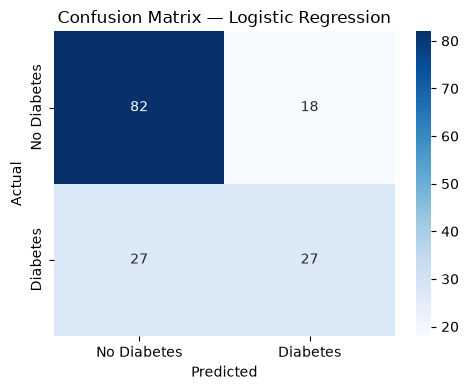

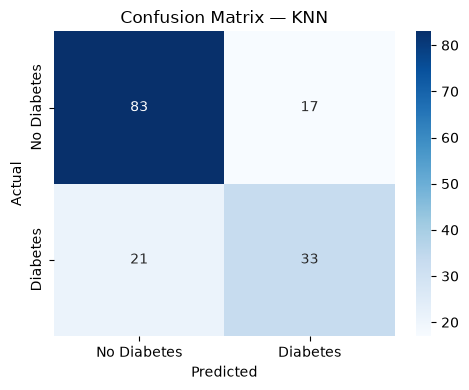

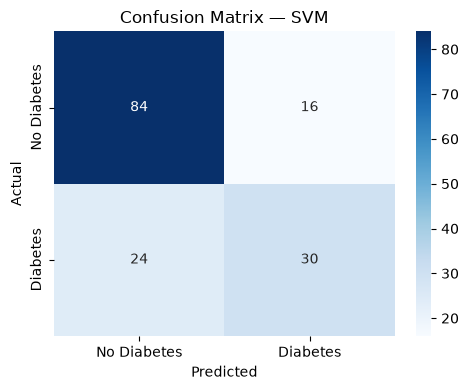

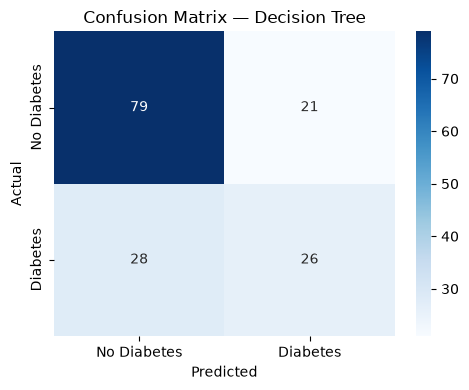

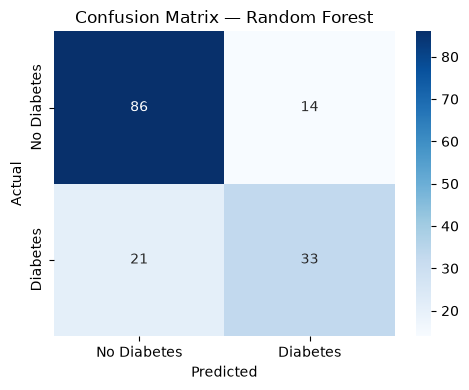

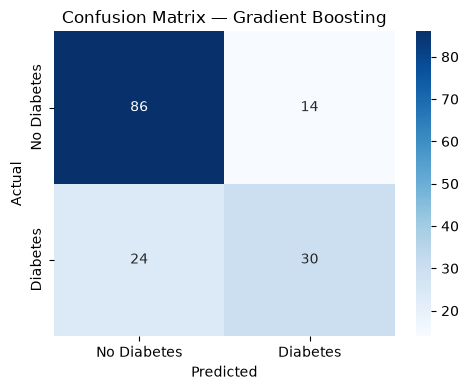

In [11]:
for name, model in models.items():
    y_pred = predictions[name]
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Diabetes", "Diabetes"],
        yticklabels=["No Diabetes", "Diabetes"]
    )
    
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.tight_layout()
    plt.show()

## Confusion Matrix — Observations

The confusion matrices show differences in the types of classification errors
made by the candidate models.

Random Forest and Gradient Boosting both produce 86 true negatives and
14 false positives.

Random Forest produces 33 true positives and 21 false negatives, while
Gradient Boosting produces 30 true positives and 24 false negatives.

KNN also produces 33 true positives and 21 false negatives.

Logistic Regression produces 27 true positives and 27 false negatives.

Decision Tree produces 26 true positives and 28 false negatives.

These results show that the models make different trade-offs between false
positive and false negative predictions. Therefore, confusion matrices should
be considered together with precision, recall, F1-score, and ROC-AUC rather
than using a single metric for model assessment.

## 8. Classification Reports

Classification reports provide precision, recall, and F1-score separately for
each target class.

This provides more detail than the overall metric table and helps identify
whether model performance differs between the two classes.

In [12]:
for name in models:
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["No Diabetes", "Diabetes"],
            digits=4,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

 No Diabetes     0.7523    0.8200    0.7847       100
    Diabetes     0.6000    0.5000    0.5455        54

    accuracy                         0.7078       154
   macro avg     0.6761    0.6600    0.6651       154
weighted avg     0.6989    0.7078    0.7008       154

KNN
              precision    recall  f1-score   support

 No Diabetes     0.7981    0.8300    0.8137       100
    Diabetes     0.6600    0.6111    0.6346        54

    accuracy                         0.7532       154
   macro avg     0.7290    0.7206    0.7242       154
weighted avg     0.7497    0.7532    0.7509       154

SVM
              precision    recall  f1-score   support

 No Diabetes     0.7778    0.8400    0.8077       100
    Diabetes     0.6522    0.5556    0.6000        54

    accuracy                         0.7403       154
   macro avg     0.7150    0.6978    0.7038       154
weighted avg     0.7337    0.7403    0.7349   

## 8.1 Class-Specific Performance Summary

The Diabetes class (`Outcome = 1`) is examined separately because it represents
the positive risk class.

Precision, recall, and F1-score are extracted for the Diabetes class for each
candidate model.

In [13]:
classification_results = []

for name in models:
    report = classification_report(
        y_test,
        predictions[name],
        output_dict=True,
        zero_division=0
    )
    
    classification_results.append({
        "Model": name,
        "Diabetes Precision": report["1"]["precision"],
        "Diabetes Recall": report["1"]["recall"],
        "Diabetes F1": report["1"]["f1-score"]
    })

class_results_df = pd.DataFrame(classification_results)

class_results_df.round(4)

,Model,Diabetes Precision,Diabetes Recall,Diabetes F1
0,Logistic Regression,0.6000,0.5000,0.5455
1,KNN,0.6600,0.6111,0.6346
2,SVM,0.6522,0.5556,0.6000
3,Decision Tree,0.5532,0.4815,0.5149
4,Random Forest,0.7021,0.6111,0.6535
5,Gradient Boosting,0.6818,0.5556,0.6122


## Observation

The class-specific metrics show how effectively each model identifies the
positive diabetes class.

Recall is particularly important to monitor because a false negative occurs
when an actual positive case is classified as negative.

However, no final model is selected from recall alone. The complete evaluation
will consider recall together with precision, F1-score, ROC-AUC, confusion
matrices, and later cross-validation results.

## 9. ROC Curves

Receiver Operating Characteristic (ROC) curves show the relationship between
the true positive rate and false positive rate across different classification
thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to
distinguish between the two target classes.

A higher ROC-AUC indicates better class discrimination on the evaluated test
set, but it should be interpreted together with the other evaluation metrics.

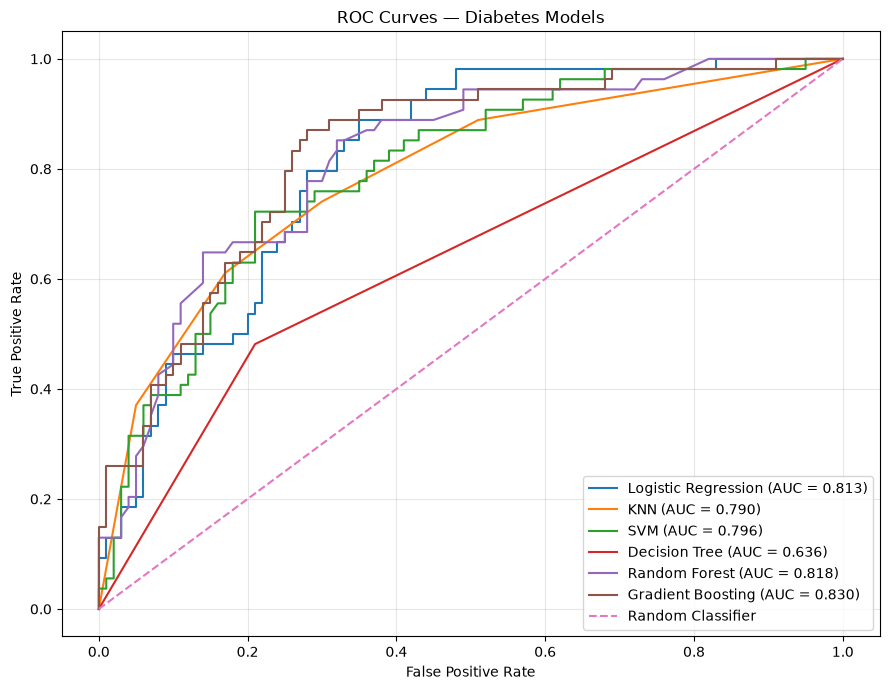

In [14]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))

for name in models:
    y_prob = probabilities[name]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves — Diabetes Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Baseline Model Evaluation Summary

Six baseline classification models were evaluated on the same unseen test
dataset of 154 samples.

The evaluation used:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Class-specific performance

### Key Findings

The baseline models produced different performance profiles across the
evaluation metrics.

`Gradient Boosting` achieved a ROC-AUC of approximately 0.830 on the test
split, while `Random Forest` achieved approximately 0.818.

`Random Forest` achieved an accuracy of approximately 0.773 and a Diabetes
class F1-score of approximately 0.654.

`KNN` achieved an accuracy of approximately 0.753 and a Diabetes class
recall of approximately 0.611.

The Decision Tree produced lower baseline performance across the evaluated
metrics compared with the other candidate models.

### Interpretation

No final model is selected solely from the baseline test-set results.

The results will be used as a baseline for the next stage, where model
hyperparameters will be tuned and evaluated using cross-validation on the
training data.

The test set will remain reserved for final evaluation.